![snap](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# GetAround

[GetAround](https://www.getaround.com/?wpsrc=Google+Organic+Search) is the Airbnb for cars. You can rent cars from any person for a few hours to a few days! Founded in 2009, this company has known rapid growth. In 2019, they count over 5 million users and about 20K available cars worldwide.

As Jedha's partner, they offered this great challenges:

## Context

When renting a car, our users have to complete a checkin flow at the beginning of the rental and a checkout flow at the end of the rental in order to:

* Assess the state of the car and notify other parties of pre-existing damages or damages that occurred during the rental.
* Compare fuel levels.
* Measure how many kilometers were driven.

The checkin and checkout of our rentals can be done with three distinct flows:
* **📱 Mobile** rental agreement on native apps: driver and owner meet and both sign the rental agreement on the owner’s smartphone
* **Connect:** the driver doesn’t meet the owner and opens the car with his smartphone
* **📝 Paper** contract (negligible)

## Project 🚧

For this case study, we suggest that you put yourselves in our shoes, and run an analysis we made back in 2017 🔮 🪄

When using Getaround, drivers book cars for a specific time period, from an hour to a few days long. They are supposed to bring back the car on time, but it happens from time to time that drivers are late for the checkout.

Late returns at checkout can generate high friction for the next driver if the car was supposed to be rented again on the same day : Customer service often reports users unsatisfied because they had to wait for the car to come back from the previous rental or users that even had to cancel their rental because the car wasn’t returned on time.


## Goals 🎯

In order to mitigate those issues we’ve decided to implement a minimum delay between two rentals. A car won’t be displayed in the search results if the requested checkin or checkout times are too close from an already booked rental.

It solves the late checkout issue but also potentially hurts Getaround/owners revenues: we need to find the right trade off.

**Our Product Manager still needs to decide:**
* **threshold:** how long should the minimum delay be?
* **scope:** should we enable the feature for all cars?, only Connect cars?

In order to help them make the right decision, they are asking you for some data insights. Here are the first analyses they could think of, to kickstart the discussion. Don’t hesitate to perform additional analysis that you find relevant.

* Which share of our owner’s revenue would potentially be affected by the feature?
* How many rentals would be affected by the feature depending on the threshold and scope we choose?
* How often are drivers late for the next check-in? How does it impact the next driver?
* How many problematic cases will it solve depending on the chosen threshold and scope?

### Web dashboard

First build a dashboard that will help the product Management team with the above questions. You can use `streamlit` or any other technology that you see fit.


### Machine Learning - `/predict` endpoint

In addition to the above question, the Data Science team is working on *pricing optimization*. They have gathered some data to suggest optimum prices for car owners using Machine Learning.

You should provide at least **one endpoint** `/predict`. The full URL would look like something like this: `https://your-url.com/predict`.

This endpoint accepts **POST method** with JSON input data and it should return the predictions. We assume **inputs will be always well formatted**. It means you do not have to manage errors. We leave the error handling as a bonus.

Input example:

```
{
  "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8], [7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
}
```

The response should be a JSON with one key `prediction` corresponding to the prediction.

Response example:

```
{
  "prediction":[6,6]
}
```

### Documentation page

You need to provide the users with a **documentation** about your API.

It has to be located at the `/docs` of your website. If we take the URL example above, it should be located directly at `https://your-url.com/docs`).

This small documentation should at least include:
- An h1 title: the title is up to you.
- A description of every endpoints the user can call with the endpoint name, the HTTP method, the required input and the expected output (you can give example).

You are free to add other any other relevant informations and style your HTML as you wish.

### Online production

You have to **host your API online**. We recommend you to use [Hugging Face](https://huggingface.co/spaces) as it is free of charge. But you are free to choose any other hosting provider.

## Helpers 🦮

To help you start with this project we provide you with some pieces of advice:

* Spend some time understanding data
* Don't overlook Data Analysis part, there is a lot of insights to find out.
* Data Analysis should take 2 to 5 hours
* Machine Learning should take 3 to 6 hours
* You are not obligated to use libraries to handle your Machine Learning workflow like `mlflow` but we definitely advise you to do so.


### Share your code

In order to get evaluation, do not forget to share your code on a [Github](https://github.com/) repository. You can create a [`README.md`](https://guides.github.com/features/mastering-markdown/) file with a quick description about this project, how to setup locally and the online URL.

## Deliverable 📬

To complete this project, you should deliver:

- A **dashboard** in production (accessible via a web page for example)
- The **whole code** stored in a **Github repository**. You will include the repository's URL.
- An **documented online API** on Hugging Face server (or any other provider you choose) containing at least **one `/predict` endpoint** that respects the technical description above. We should be able to request the API endpoint `/predict` using `curl`:

```shell
$ curl -i -H "Content-Type: application/json" -X POST -d '{"input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]}' http://your-url/predict
```

Or Python:

```python
import requests

response = requests.post("https://your-url/predict", json={
    "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
})
print(response.json())
```

## Data

There are two files you need to download:

* [Delay Analysis](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_delay_analysis.xlsx) 👈 Data Analysis
* [Pricing Optimization](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_pricing_project.csv) 👈 Machine Learning


Happy coding! 👩‍💻

#1. Data Cleaning & Preprocessing

In [1]:
from google.colab import files
uploaded = files.upload()


Saving get_around_delay_analysis.xlsx to get_around_delay_analysis.xlsx


In [2]:
import pandas as pd

df_delay = pd.read_excel("get_around_delay_analysis.xlsx")

print(df_delay.shape)
df_delay.head()


(21310, 7)


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


"connect" → Connect cars (no owner physically present, unlock via app).
"mobile" → Mobile check-in (owner is present and handles the key exchange).

In [3]:
# Check dataset structure
df_delay.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


In [4]:
df_delay.describe(include='all')

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,21310,21310,16346.000000,1841.000000,1841.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,17003,18045,NaN,NaN,NaN
mean,549712.880338,350030.603426,NaN,NaN,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,NaN,NaN,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,NaN,NaN,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,NaN,NaN,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,NaN,NaN,67.000000,560823.000000,540.000000


In [5]:
# Count missing values in each column
df_delay.isna().sum()


,0
rental_id,0
car_id,0
checkin_type,0
state,0
delay_at_checkout_in_minutes,4964
previous_ended_rental_id,19469
time_delta_with_previous_rental_in_minutes,19469


In [6]:
#Handle missing values

# 1. Drop rows with missing delay
df_delay = df_delay.dropna(subset=["delay_at_checkout_in_minutes"])

# 2. Drop column not needed
df_delay = df_delay.drop(columns=["previous_ended_rental_id"])

# 3. Fill missing gaps with 0
df_delay["time_delta_with_previous_rental_in_minutes"] = (
    df_delay["time_delta_with_previous_rental_in_minutes"].fillna(0)
)


In [7]:
df_delay.describe(include='all')

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,time_delta_with_previous_rental_in_minutes
count,16346.000000,16346.000000,16346,16346,16346.000000,16346.000000
unique,NaN,NaN,2,2,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN
freq,NaN,NaN,12944,16345,NaN,NaN
mean,549860.510522,349017.233452,NaN,NaN,59.701517,25.661324
std,13587.634925,58268.394226,NaN,NaN,1002.561635,111.640319
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,0.000000
25%,540869.250000,316924.000000,NaN,NaN,-36.000000,0.000000
50%,550403.000000,367531.000000,NaN,NaN,9.000000,0.000000
75%,560268.500000,393750.000000,NaN,NaN,67.000000,0.000000


In [8]:
# checkinh missing values again :

df_delay.isna().sum()


,0
rental_id,0
car_id,0
checkin_type,0
state,0
delay_at_checkout_in_minutes,0
time_delta_with_previous_rental_in_minutes,0


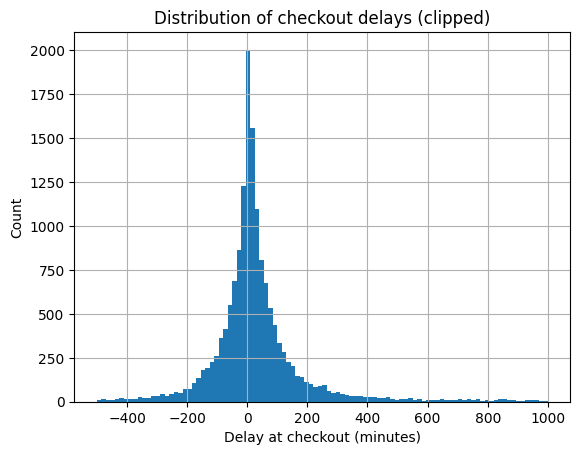

In [9]:
import matplotlib.pyplot as plt

df_delay["delay_at_checkout_in_minutes"].hist(bins=100, range=(-500, 1000))
plt.title("Distribution of checkout delays (clipped)")
plt.xlabel("Delay at checkout (minutes)")
plt.ylabel("Count")
plt.show()


We limit the histogram range (e.g. –500 to +1000):

It hides the crazy outliers.

It zooms in on the bulk of realistic delays, which is what we care about for buffer policy.


 Interpretation of the histogram

X-axis (Delay at checkout, in minutes)

Negative values → the car was returned early (before the agreed time).
Positive values → the car was returned late (after the agreed time).

Y-axis (Count)

Number of rentals falling in each delay range.

What we see
Strong peak around 0 minutes
Most users return the car on time or very close to the scheduled checkout.
Slight skew to the right (positive side)
Many users return a bit late (0 to +200 minutes).

This is important because these cases are the ones that may cause conflicts for the next renter.


In [10]:
df_delay["time_delta_with_previous_rental_in_minutes"].describe()


,time_delta_with_previous_rental_in_minutes
count,16346.000000
mean,25.661324
std,111.640319
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,720.000000


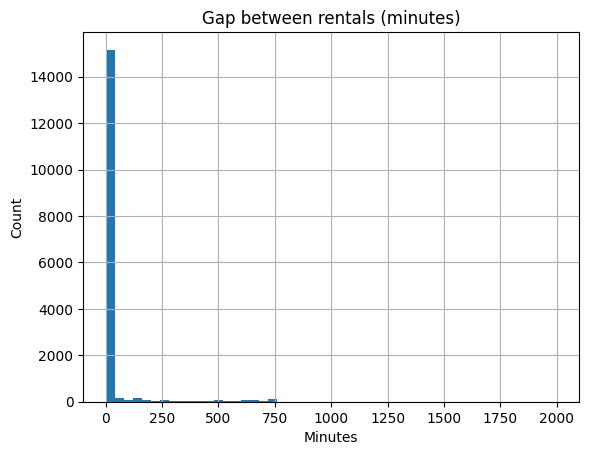

In [11]:
df_delay["time_delta_with_previous_rental_in_minutes"].hist(bins=50, range=(0, 2000))
plt.title("Gap between rentals (minutes)")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()


In [12]:
#remove outliers for checkout delays

df_delay = df_delay[
    (df_delay["delay_at_checkout_in_minutes"] >= -500) &
    (df_delay["delay_at_checkout_in_minutes"] <= 1500)
]


In [13]:
df_delay.shape


(15805, 6)

In [14]:
df_delay.describe(include='all')

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,time_delta_with_previous_rental_in_minutes
count,15805.000000,15805.000000,15805,15805,15805.000000,15805.000000
unique,NaN,NaN,2,1,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN
freq,NaN,NaN,12519,15805,NaN,NaN
mean,549840.105853,349061.906359,NaN,NaN,41.885543,25.630497
std,13601.123934,58145.139447,NaN,NaN,200.971469,111.472520
min,504806.000000,159250.000000,NaN,NaN,-500.000000,0.000000
25%,540876.000000,316892.000000,NaN,NaN,-31.000000,0.000000
50%,550377.000000,367535.000000,NaN,NaN,10.000000,0.000000
75%,560242.000000,393628.000000,NaN,NaN,66.000000,0.000000


# 2. Exploratory Data Analysis (EDA)

In [15]:
# Question 1 — How often are drivers late for checkout?

# Create late_return column
df_delay["late_return"] = df_delay["delay_at_checkout_in_minutes"] > 0

# Percentage of late returns
late_rate = df_delay["late_return"].mean() * 100
late_rate


np.float64(58.49414742170199)

Result: ~58.5% of rentals are returned late.
That means more than half of users don’t bring back the car on time — a big issue for Getaround.

In [16]:
#Question 2 — How does lateness impact the next driver?

# time_delta_with_previous_rental_in_minutes :  is the gap (in minutes) between the end of the previous rental of the same car and the start of the current rental.

# Create conflict column
df_delay["conflict"] = (
    df_delay["delay_at_checkout_in_minutes"] > df_delay["time_delta_with_previous_rental_in_minutes"]
)

# Percentage of conflicts
conflict_rate = df_delay["conflict"].mean() * 100
conflict_rate


np.float64(55.1281240113888)

Result: ~55.1% of rentals caused a conflict (delay longer than the gap).

This means that not only are 58% of rentals late, but in more than half of the cases the next renter is directly impacted.

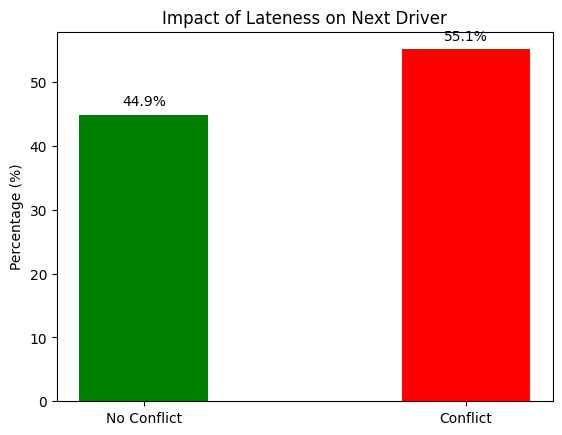

In [17]:
labels = ["No Conflict", "Conflict"]
sizes = [
    (~df_delay["conflict"]).mean() * 100,
    df_delay["conflict"].mean() * 100
]

bars = plt.bar(labels, sizes, color=["green", "red"], width=0.4)
plt.title("Impact of Lateness on Next Driver")
plt.ylabel("Percentage (%)")

# Add labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%",
             ha="center", va="bottom")

plt.show()




In [18]:
# Question 3 — How many rentals would be affected if we add a buffer?

thresholds = [30, 60, 120, 180, 240]  #These are the minimum buffer values we want to test (in minutes).
results = {}

for t in thresholds:
    blocked = (df_delay["time_delta_with_previous_rental_in_minutes"] < t).mean() * 100
    results[t] = blocked

results


{30: np.float64(92.10376463144576),
 60: np.float64(92.76178424549192),
 120: np.float64(94.1031319202784),
 180: np.float64(95.19772223979753),
 240: np.float64(95.82410629547611)}

Interpretation

These numbers are very high it suggests that almost all rentals would be blocked if we add even a 30-minute buffer.

Blocking 90–95% of rentals would severely hurt Getaround’s revenue.

This shows the trade-off: Buffer policy reduces conflicts,but it also removes a huge share of rentals from availability.

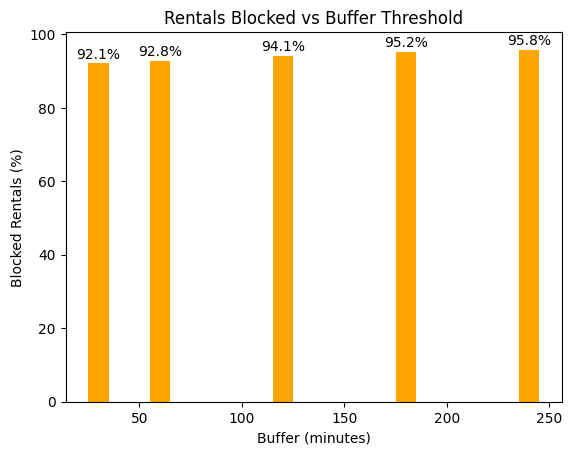

In [19]:
x = list(results.keys())
y = list(results.values())

bars = plt.bar(x, y, color="orange", width=10)  # slim bars
plt.title("Rentals Blocked vs Buffer Threshold")
plt.xlabel("Buffer (minutes)")
plt.ylabel("Blocked Rentals (%)")

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%",
             ha="center", va="bottom")

plt.show()




In [20]:
# Question 4 — How many problematic cases (conflicts) will it solve depending on the chosen threshold= buffer
# time_delta_with_previous_rental_in_minutes < t → the gap between rentals is smaller than the buffer threshold.

thresholds = [30, 60, 120, 180, 240]
conflicts_solved = {}

for t in thresholds:
    # A conflict is solved if:
    #   - it was originally a conflict
    #   - AND the gap is smaller than the buffer (so rental would be blocked)
    cond = (
        (df_delay["conflict"]) &
        (df_delay["time_delta_with_previous_rental_in_minutes"] < t)
    )
    solved = cond.mean() * 100
    conflicts_solved[t] = solved

conflicts_solved


{30: np.float64(54.34356216387219),
 60: np.float64(54.590319519139506),
 120: np.float64(54.87503954444796),
 180: np.float64(55.0079088895919),
 240: np.float64(55.03954444795951)}

Interpretation

No matter if the buffer is 30 minutes or 240 minutes, you only solve about 54–55% of conflicts.,Because most conflicts happen when delays are much larger than the gap. Even if you add a 4-hour buffer, many conflicts remain unsolved (e.g. if a renter is 8 hours late).

In [21]:
df_delay["checkin_type"].value_counts(normalize=True) * 100


,proportion
checkin_type,
mobile,79.209111
connect,20.790889


In [22]:
df_delay[df_delay["checkin_type"] == "connect"]


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,time_delta_with_previous_rental_in_minutes,late_return,conflict
2,508131,359049,connect,ended,70.0,0.0,True,True
6,511639,370585,connect,ended,-15.0,570.0,False,False
9,513434,256528,connect,ended,23.0,0.0,True,True
15,518282,364160,connect,ended,-81.0,0.0,False,False
20,519795,383720,connect,ended,-159.0,0.0,False,False
...,...,...,...,...,...,...,...,...
21279,568725,403265,connect,ended,-159.0,0.0,False,False
21282,569249,320824,connect,ended,68.0,0.0,True,True
21304,573322,376491,connect,ended,-66.0,0.0,False,False
21308,574852,362531,connect,ended,-76.0,0.0,False,False


In [23]:
#Conflicts Solved (Connect Only)
# thresholds = [30, 60, 120, 180, 240]
conflicts_solved_connect = {}

for t in thresholds:
    cond = (
        (df_delay["conflict"]) &
        (df_delay["checkin_type"] == "connect") &
        (df_delay["time_delta_with_previous_rental_in_minutes"] < t)
    )
    solved = cond.mean() * 100
    conflicts_solved_connect[t] = solved

conflicts_solved_connect


{30: np.float64(7.813982916798482),
 60: np.float64(7.883581145207214),
 120: np.float64(7.940525150268902),
 180: np.float64(7.9721607086365065),
 240: np.float64(7.978487820310029)}

When we restrict the buffer to Connect cars only, only ~8% of conflicts are solved.

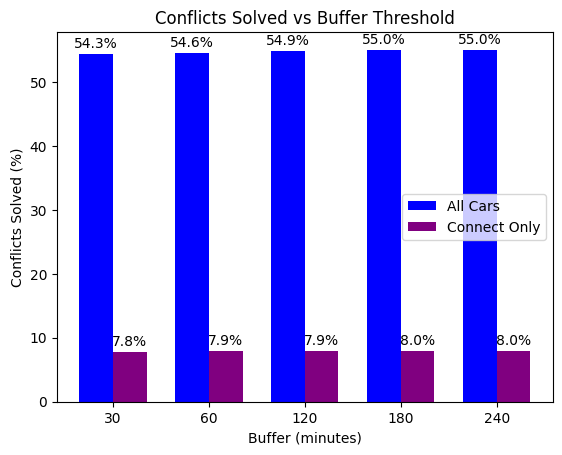

In [24]:
import numpy as np

# Data
x = np.arange(len(thresholds))  # buffer positions
width = 0.35  # bar width

all_cars = list(conflicts_solved.values())
connect_only = list(conflicts_solved_connect.values())

# Plot
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, all_cars, width, label="All Cars", color="blue")
bars2 = ax.bar(x + width/2, connect_only, width, label="Connect Only", color="purple")

# Labels & title
ax.set_title("Conflicts Solved vs Buffer Threshold")
ax.set_xlabel("Buffer (minutes)")
ax.set_ylabel("Conflicts Solved (%)")
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.legend()

# Add % labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%",
                ha="center", va="bottom")

plt.show()


Why separate Mobile vs Connect?

Mobile cars (owner present):

Higher tolerance for delays (owner can manage key exchange, wait, etc.).

Conflicts might be less harmful.

Connect cars (no owner):

More sensitive to delays.

Even small delays can cause a renter to abandon.

In [25]:
conflicts_solved_by_type = {}

for checkin in df_delay["checkin_type"].unique():
    type_results = {}
    for t in thresholds:
        cond = (
            (df_delay["conflict"]) &
            (df_delay["checkin_type"] == checkin) &
            (df_delay["time_delta_with_previous_rental_in_minutes"] < t)
        )
        solved = cond.mean() * 100
        type_results[t] = solved
    conflicts_solved_by_type[checkin] = type_results

conflicts_solved_by_type


{'mobile': {30: np.float64(46.52957924707371),
  60: np.float64(46.706738373932296),
  120: np.float64(46.934514394179054),
  180: np.float64(47.035748180955395),
  240: np.float64(47.06105662764948)},
 'connect': {30: np.float64(7.813982916798482),
  60: np.float64(7.883581145207214),
  120: np.float64(7.940525150268902),
  180: np.float64(7.9721607086365065),
  240: np.float64(7.978487820310029)}}

Mobile cars

~46–47% of conflicts solved (no matter if buffer = 30 or 240 min).

Most of the effect of buffer policies comes from here.

Connect cars

Only ~7–8% of conflicts solved.

Much lower, because Connect cars are fewer in your dataset.

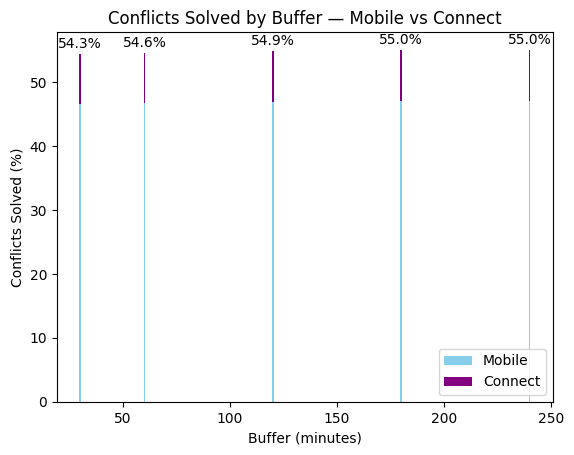

In [26]:
# Extract data
mobile = list(conflicts_solved_by_type["mobile"].values())
connect = list(conflicts_solved_by_type["connect"].values())

x = thresholds

# Plot
plt.bar(x, mobile, label="Mobile", color="skyblue")
plt.bar(x, connect, bottom=mobile, label="Connect", color="purple")

# Labels & title
plt.title("Conflicts Solved by Buffer — Mobile vs Connect")
plt.xlabel("Buffer (minutes)")
plt.ylabel("Conflicts Solved (%)")
plt.legend()

# Add % labels on top of stacked bars
for i in range(len(x)):
    total = mobile[i] + connect[i]
    plt.text(x[i], total + 0.5, f"{total:.1f}%", ha="center", va="bottom")

plt.show()


The results show : all cars → buffer solves about 55% of conflicts, not 100%.

Mobile only → ~47% solved.
Connect only → ~8% solved.

Conclusion of EDA

Buffer policy reduces conflicts, but it will never eliminate them.

That’s why Getaround may also need other solutions (penalties... )

In [27]:
# Keep only the columns needed by the dashboard and save as CSV
cols = [
    "rental_id","car_id","checkin_type","state",
    "delay_at_checkout_in_minutes","time_delta_with_previous_rental_in_minutes"
]
df_delay[cols].to_csv("delays_clean.csv", index=False)


In [28]:
# Download to your computer from Colab
from google.colab import files
files.download("delays_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>